In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import linregress

import warnings
warnings.filterwarnings("ignore")

In [2]:
DATA_DIR = Path(
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\BOXED"
)

In [8]:
def plot_oras5_variable(file_token, variable_label):

    files = sorted(DATA_DIR.glob(f"*{file_token}*.nc"))

    print(f"Found {len(files)} files")

    if len(files) == 0:
        raise FileNotFoundError(
            f"No files found containing '{file_token}'"
        )

    monthly_values = []
    monthly_times = []

    for file in files:

        ds = xr.open_dataset(file)

        # Find data variable automatically
        # Find the main data variable
        numeric_vars = [
            v for v in ds.data_vars
            if np.issubdtype(ds[v].dtype, np.number)
        ]

        # print(file.name, numeric_vars)

        var_name = numeric_vars[0]
        da = ds[var_name]

        # Remove large fill values
        da = da.where(np.abs(da) < 1e10)

        # Average over all dimensions except time
        spatial_dims = [
            d for d in da.dims
            if d.lower() not in ["time", "time_counter"]
        ]

        value = da.mean(dim=spatial_dims, skipna=True)

        monthly_values.append(float(value.values))

        year = int(file.name.split("_")[1])
        month = int(file.name.split("_")[2])

        monthly_times.append(
            pd.Timestamp(year=year, month=month, day=15)
        )

        ds.close()

    df = pd.DataFrame({
        "time": monthly_times,
        "value": monthly_values
    })

    annual = (
        df
        .set_index("time")
        .resample("YS")
        .mean()
        .reset_index()
    )

    annual["year"] = annual["time"].dt.year

    x = annual["year"].values
    y = annual["value"].values

    slope, intercept, r, p, stderr = linregress(x, y)

    fit = intercept + slope * x

    plt.figure(figsize=(8,4))

    plt.plot(
        annual["year"],
        y,
        marker="o",
        lw=1.5,
        label="Annual Mean"
    )

    plt.plot(
        annual["year"],
        fit,
        "--",
        label=f"Trend ({slope:.4g}/yr)"
    )

    plt.title(variable_label)

    plt.xlabel("Year")
    plt.ylabel(variable_label)

    plt.grid(alpha=0.3)

    plt.legend()

    plt.tight_layout()

    plt.show()

    print(f"Slope = {slope:.6g} ± {stderr:.6g} per year")
    print(f"R² = {r**2:.4f}")
    print(f"p = {p:.3e}")

    return annual

Found 798 files


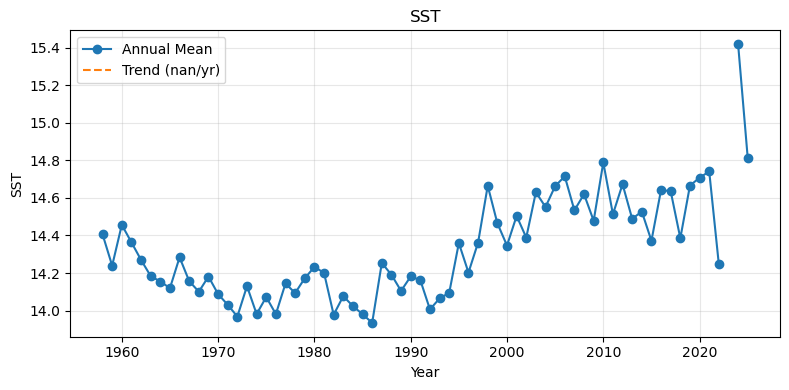

Slope = nan ± nan per year
R² = nan
p = nan


In [4]:
sst_df = plot_oras5_variable(
    "sst_boxed",
    "SST"
)

Found 795 files
ORAS5_1958_01_so_salinity_boxed.nc ['vosaline']
ORAS5_1958_02_so_salinity_boxed.nc ['vosaline']
ORAS5_1958_03_so_salinity_boxed.nc ['vosaline']
ORAS5_1958_04_so_salinity_boxed.nc ['vosaline']
ORAS5_1958_05_so_salinity_boxed.nc ['vosaline']
ORAS5_1958_06_so_salinity_boxed.nc ['vosaline']
ORAS5_1958_07_so_salinity_boxed.nc ['vosaline']
ORAS5_1958_08_so_salinity_boxed.nc ['vosaline']
ORAS5_1958_09_so_salinity_boxed.nc ['vosaline']
ORAS5_1958_10_so_salinity_boxed.nc ['vosaline']
ORAS5_1958_11_so_salinity_boxed.nc ['vosaline']
ORAS5_1958_12_so_salinity_boxed.nc ['vosaline']
ORAS5_1959_01_so_salinity_boxed.nc ['vosaline']
ORAS5_1959_02_so_salinity_boxed.nc ['vosaline']
ORAS5_1959_03_so_salinity_boxed.nc ['vosaline']
ORAS5_1959_04_so_salinity_boxed.nc ['vosaline']
ORAS5_1959_05_so_salinity_boxed.nc ['vosaline']
ORAS5_1959_06_so_salinity_boxed.nc ['vosaline']
ORAS5_1959_07_so_salinity_boxed.nc ['vosaline']
ORAS5_1959_08_so_salinity_boxed.nc ['vosaline']
ORAS5_1959_09_so_salinit

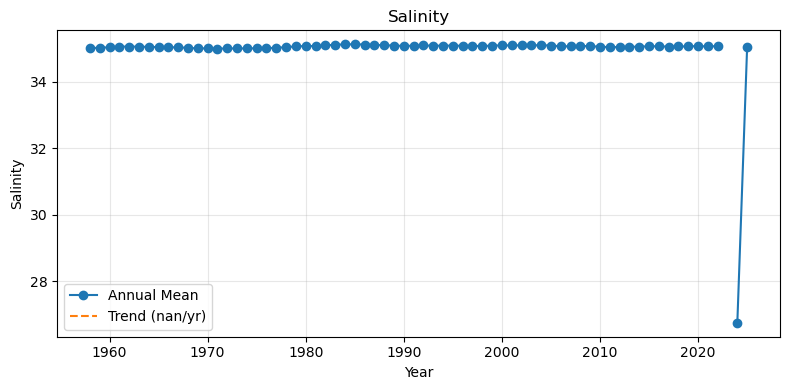

Slope = nan ± nan per year
R² = nan
p = nan


In [7]:
sal_df = plot_oras5_variable(
    "so_salinity_boxed",
    "Salinity"
)

Found 798 files


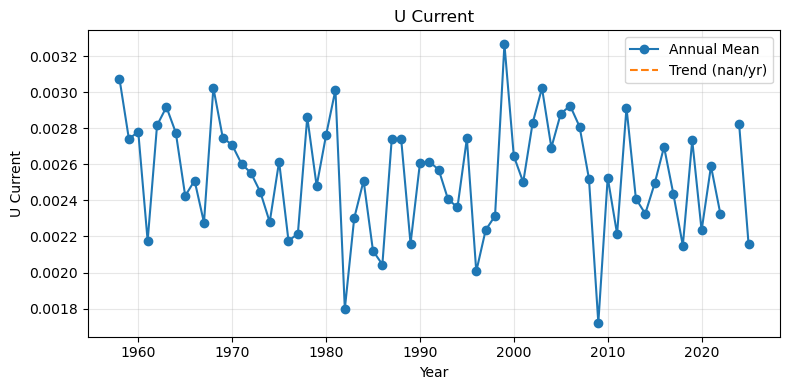

Slope = nan ± nan per year
R² = nan
p = nan


In [9]:
u_df = plot_oras5_variable(
    "u_zonal_boxed",
    "U Current"
)

Found 798 files


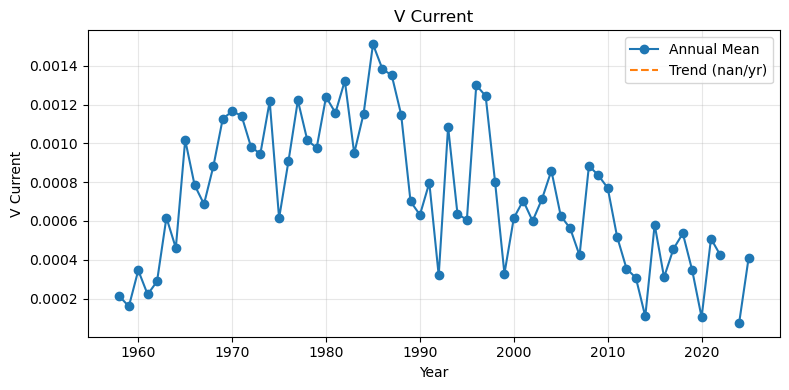

Slope = nan ± nan per year
R² = nan
p = nan


In [10]:
v_df = plot_oras5_variable(
    "v_meridional_boxed",
    "V Current"
)

Found 798 files


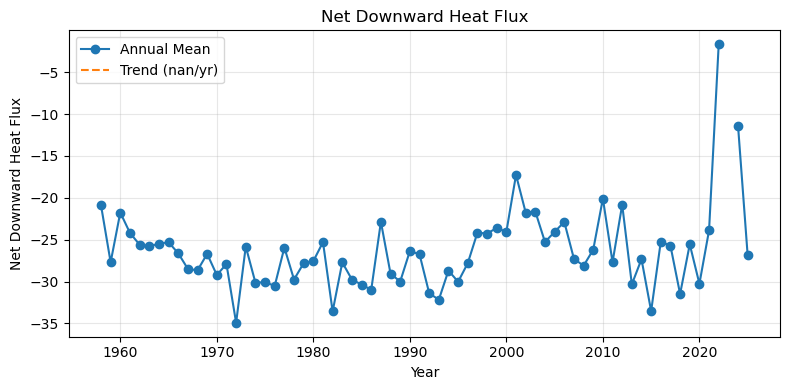

Slope = nan ± nan per year
R² = nan
p = nan


In [11]:
heat_df = plot_oras5_variable(
    "net_downward_heat_flux_boxed",
    "Net Downward Heat Flux"
)

Found 797 files


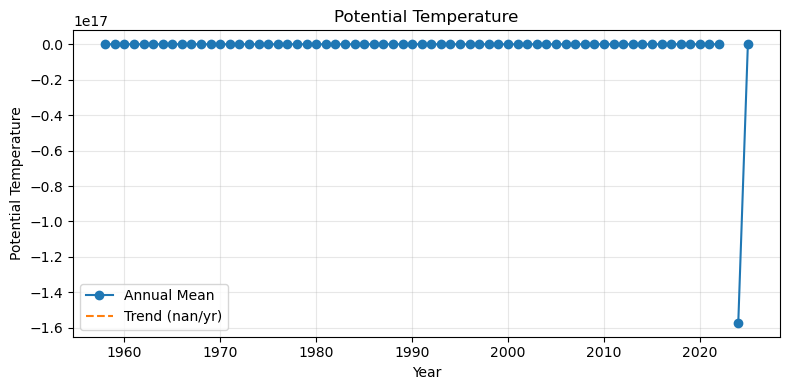

Slope = nan ± nan per year
R² = nan
p = nan


In [12]:
thetao_df = plot_oras5_variable(
    "thetao_potential_temperature_boxed",
    "Potential Temperature"
)